# Klasifikasi Tangisan Bayi — Intermediate Fusion (Citra + Audio)

Pendekatan yang dipakai di notebook ini:

| Aspek | Keputusan |
|---|---|
| **Unit data** | **1 video = 1 sample** (beberapa frame diringkas jadi 1 vektor fitur lewat rata-rata, bukan dijadikan baris data terpisah) |
| **Cabang citra** | **Transfer learning** — backbone pretrained ImageNet yang dibekukan, hanya layer proyeksi kecil di atasnya yang dilatih |
| **Cabang audio** | CNN kecil dilatih dari nol (spektogram bukan gambar natural, manfaat pretrained lebih kecil) |
| **Titik fusi** | `Concatenate` di level fitur → **intermediate / feature-level fusion** |
| **Split** | 2 arah: train / val (tanpa test terpisah) |
| **Metrik** | Accuracy + **macro F1** (lebih adil saat jumlah data antar kelas tidak seimbang) |

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from pathlib import Path
from moviepy import VideoFileClip
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Konfigurasi

In [11]:
VIDEO_DIR = 'Data_Video_Bayi'
WORK_DIR  = 'work'
FRAME_DIR = os.path.join(WORK_DIR, 'frames')
SPEC_DIR  = os.path.join(WORK_DIR, 'spectrograms')

BACKBONE = 'resnet'
FRAME_SIZE = (224, 224)
N_CHANNELS = 3

SPEC_SIZE     = (64, 128)
SPEC_CHANNELS = 1

N_FRAMES_PER_VIDEO = 5
BATCH_SIZE = 8
EPOCHS     = 100
SEED       = 42

TRAIN_DIR_NAMES = ['data_train_video']
TEST_DIR_NAMES  = ['data_test_video']

CLASS_NAMES = ['eh', 'heh', 'neh', 'owh']
N_CLASSES   = len(CLASS_NAMES)

MEANINGS = {'eairh': 'Tidak nyaman perut bawah', 'eh': 'Perlu bersendawa',
            'heh': 'Tidak nyaman', 'neh': 'Lapar', 'owh': 'Mengantuk'}

RESULTS_DIR = 'results'

for d in [FRAME_DIR, SPEC_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)

## Ekstraksi dari video

Tiap video menghasilkan **satu** sample: beberapa frame citra + **satu** spektogram dari audio penuh
(audio tidak dipotong per segmen, karena klip yang pendek bisa membuat pola tangisan terpenggal).

In [12]:
def extract_video_sample(video_path, frame_prefix, spec_prefix, n_frames=N_FRAMES_PER_VIDEO, frame_size=FRAME_SIZE):
    try:
        clip = VideoFileClip(video_path)
        audio = clip.audio
    except Exception as e:
        print(f"  Gagal load video: {Path(video_path).name} ({e})")
        return None
    if audio is None:
        clip.close()
        return None

    tmp_wav = f"{spec_prefix}_tmp.wav"
    audio.write_audiofile(tmp_wav, logger=None)
    clip.close()

    X, sr = librosa.load(tmp_wav, sr=None, res_type='kaiser_fast')
    os.remove(tmp_wav)
    if X.size == 0:
        return None

    S = librosa.feature.melspectrogram(y=X, sr=sr, n_mels=SPEC_SIZE[0])
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)     # normalisasi antar video

    # Simpan nilai mel sebagai grayscale (tanpa colormap, tanpa sumbu matplotlib).
    lo, hi = S_db.min(), S_db.max()
    pixels = ((S_db - lo) / (hi - lo + 1e-6) * 255).astype(np.uint8)
    spec_out = f"{spec_prefix}.png"
    Image.fromarray(np.flipud(pixels)).resize((SPEC_SIZE[1], SPEC_SIZE[0])).save(spec_out)

    # Beberapa frame tersebar merata di sepanjang durasi video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total / fps if fps > 0 else 0

    frame_paths = []
    for i in range(n_frames):
        target = duration * (i + 0.5) / n_frames if duration > 0 else 0.0
        cap.set(cv2.CAP_PROP_POS_MSEC, target * 1000)
        ok, frame = cap.read()
        if not ok:
            continue
        out = f"{frame_prefix}_f{i}.png"
        plt.imsave(out, cv2.cvtColor(cv2.resize(frame, frame_size), cv2.COLOR_BGR2RGB))
        frame_paths.append(out)
    cap.release()

    if not frame_paths:
        return None
    while len(frame_paths) < n_frames:      # Apabila klip sangat pendek, maka ulang frame terakhir
        frame_paths.append(frame_paths[-1])

    return frame_paths, spec_out

In [13]:
VIDEO_EXTENSIONS = ('.mp4', '.mov', '.avi', '.mkv')

def list_videos(class_dir, dir_names):
    found = []
    for name in dir_names:
        d = class_dir / name
        if d.is_dir():
            found += [p for p in d.glob('*') if p.suffix.lower() in VIDEO_EXTENSIONS]
    return found

samples = []

for class_name in CLASS_NAMES:
    class_dir = Path(VIDEO_DIR) / class_name
    if not class_dir.is_dir():
        print(f"Lewati (folder tidak ada): {class_dir}")
        continue

    train_videos = list_videos(class_dir, TRAIN_DIR_NAMES)
    test_videos  = list_videos(class_dir, TEST_DIR_NAMES)
    print(f"{class_name}: {len(train_videos)} video di folder train, {len(test_videos)} video di folder test")

    for origin, video_paths in [('trainval', train_videos), ('test', test_videos)]:
        for video_path in video_paths:
            stem = video_path.stem
            result = extract_video_sample(
                str(video_path),
                os.path.join(FRAME_DIR, f"{class_name}_{stem}"),
                os.path.join(SPEC_DIR, f"{class_name}_{stem}"),
            )
            if result is None:
                continue
            frame_paths, spec_path = result
            samples.append({'frame_paths': frame_paths, 'spec_path': spec_path,
                            'label': CLASS_NAMES.index(class_name),
                            'video_id': f"{class_name}_{stem}",
                            'origin': origin})

df_samples = pd.DataFrame(samples)
print(f"\nTotal: {len(df_samples)} video = {len(df_samples)} sample\n")
print(pd.crosstab(df_samples['label'].map(dict(enumerate(CLASS_NAMES))), df_samples['origin']))

eh: 28 video di folder train, 7 video di folder test
heh: 28 video di folder train, 7 video di folder test
neh: 28 video di folder train, 7 video di folder test
owh: 28 video di folder train, 7 video di folder test

Total: 140 video = 140 sample

origin  test  trainval
label                 
eh         7        28
heh        7        28
neh        7        28
owh        7        28


### Periksa hasil ekstraksi secara visual

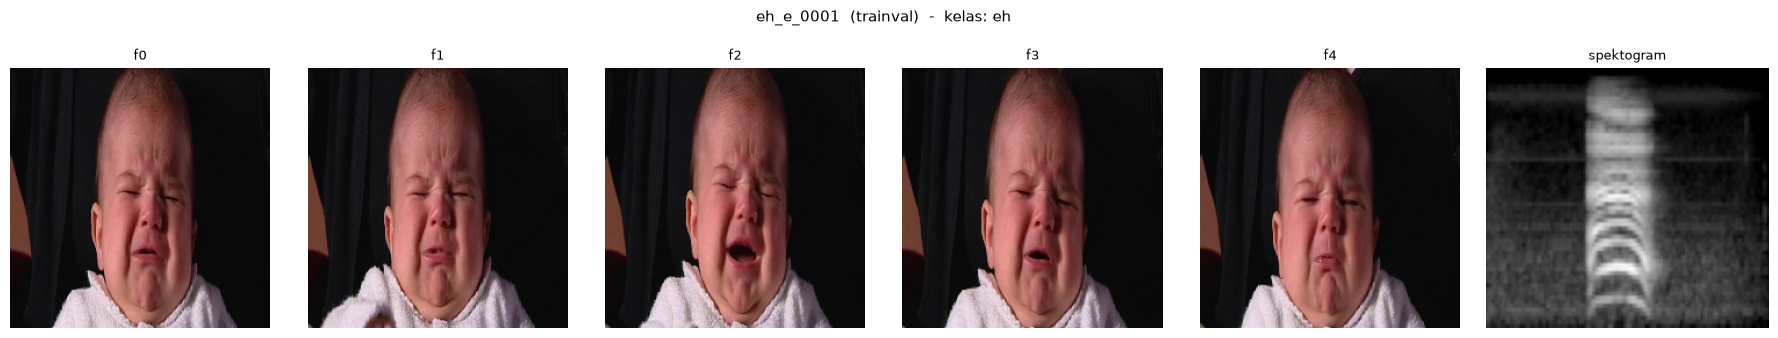

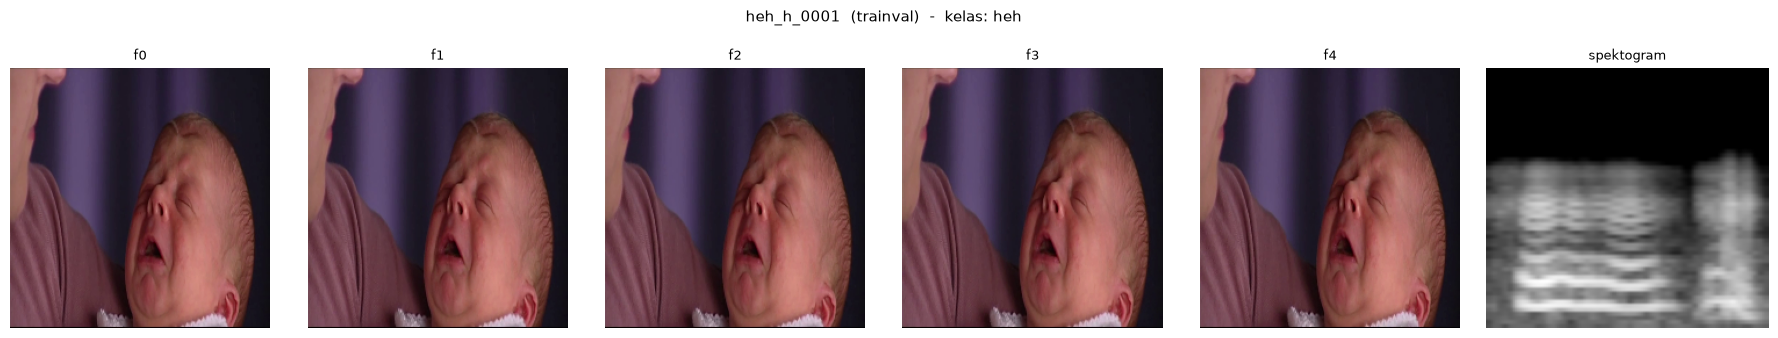

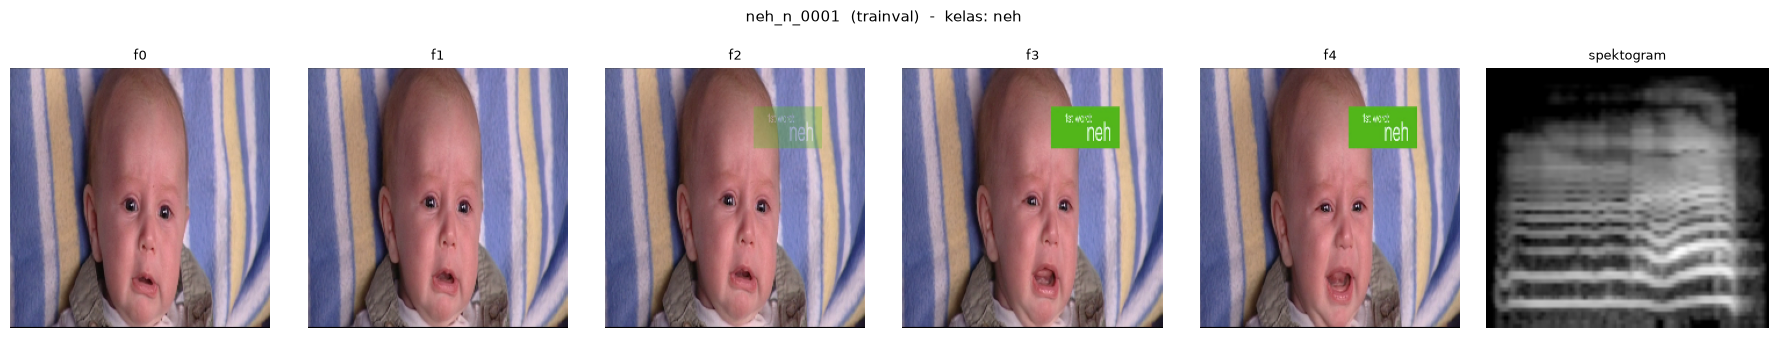

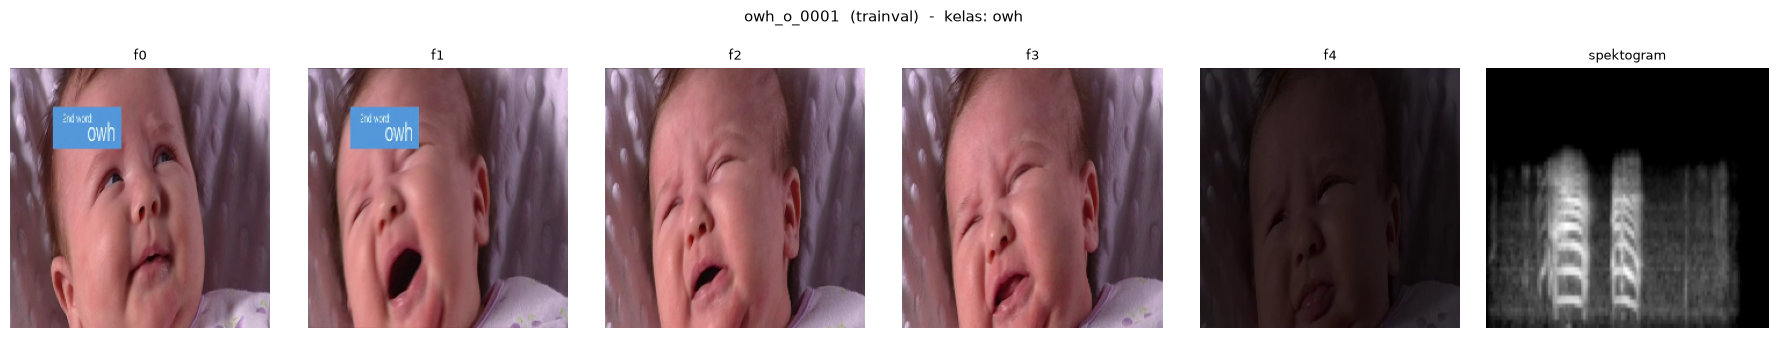

In [14]:
def preview_sample(row):
    """Tampilkan semua frame + spektogram dari satu video."""
    n = len(row['frame_paths'])
    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3.4))
    for i, p in enumerate(row['frame_paths']):
        axes[i].imshow(plt.imread(p))
        axes[i].set_title(f"f{i}", fontsize=9)
        axes[i].axis('off')

    axes[-1].imshow(plt.imread(row['spec_path']), cmap='gray', aspect='auto')
    axes[-1].set_title('spektogram', fontsize=9)
    axes[-1].axis('off')

    fig.suptitle(f"{row['video_id']}  ({row['origin']})  -  kelas: {CLASS_NAMES[row['label']]}", fontsize=11)
    plt.tight_layout(); plt.show()

# Tampilkan satu contoh dari tiap kelas
for label in range(N_CLASSES):
    subset = df_samples[df_samples['label'] == label]
    if len(subset):
        preview_sample(subset.iloc[0])

## Split train / val / test

**test** sekarang diambil LANGSUNG dari video yang sudah ada di folder `data_test_video` --
bukan hasil pecahan acak dari kode. Video di folder `data_train_video` / `data_latih_video`
dipecah lagi jadi train + val.

- **train** -- untuk model belajar
- **val** -- memantau training, EarlyStopping, dan untuk eksperimen konfigurasi (boleh dilihat berkali-kali)
- **test** -- disiapkan sekarang, tapi **JANGAN dievaluasi** sampai semua keputusan konfigurasi final

In [15]:
from sklearn.model_selection import GroupShuffleSplit

def group_split(df, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(splitter.split(df, groups=df['video_id']))
    return df.iloc[idx_a], df.iloc[idx_b]

def stratified_group_split(df, test_size, seed):
    parts_a, parts_b = [], []
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label]
        a, b = group_split(subset, test_size=test_size, seed=seed)
        parts_a.append(a); parts_b.append(b)
    return pd.concat(parts_a).reset_index(drop=True), pd.concat(parts_b).reset_index(drop=True)

# test_df LANGSUNG dari folder data_test_video (bukan hasil split acak) -> paling jujur untuk dilaporkan
test_df     = df_samples[df_samples['origin'] == 'test'].reset_index(drop=True)
trainval_df = df_samples[df_samples['origin'] == 'trainval'].reset_index(drop=True)

# trainval dipecah lagi jadi train + val, tetap grup-aman & proporsional per kelas
train_df, valid_df = stratified_group_split(trainval_df, test_size=0.2, seed=SEED)

# Sanity check eksplisit: pastikan video_id di ketiga sisi benar-benar terpisah total
train_ids, valid_ids, test_ids = set(train_df['video_id']), set(valid_df['video_id']), set(test_df['video_id'])
assert not (train_ids & valid_ids), "Leakage: ada video yang sama di train & valid!"
assert not (train_ids & test_ids),  "Leakage: ada video yang sama di train & test!"
assert not (valid_ids & test_ids),  "Leakage: ada video yang sama di valid & test!"

for name, d in [('Train', train_df), ('Valid', valid_df), ('Test ', test_df)]:
    dist = d['label'].value_counts().sort_index().tolist()
    print(f"{name}: {len(d):3d} video   distribusi per kelas {dict(zip(CLASS_NAMES, dist))}")

Train:  88 video   distribusi per kelas {'eh': 22, 'heh': 22, 'neh': 22, 'owh': 22}
Valid:  24 video   distribusi per kelas {'eh': 6, 'heh': 6, 'neh': 6, 'owh': 6}
Test :  28 video   distribusi per kelas {'eh': 7, 'heh': 7, 'neh': 7, 'owh': 7}


## Pipeline data

In [16]:
PREPROCESS = (tf.keras.applications.mobilenet_v2.preprocess_input if BACKBONE == 'mobilenet'
              else tf.keras.applications.resnet50.preprocess_input)

def load_frame(path):
    """Frame citra: dipreprocess sesuai backbone pretrained yang dipakai."""
    img = tf.image.decode_png(tf.io.read_file(path), channels=N_CHANNELS)
    img = tf.image.resize(img, FRAME_SIZE)
    return PREPROCESS(img)

def load_spec(path):
    """Spektogram grayscale: cukup diskalakan ke 0-1 (CNN-nya dilatih dari nol)."""
    img = tf.image.decode_png(tf.io.read_file(path), channels=SPEC_CHANNELS)
    img = tf.image.resize(img, SPEC_SIZE)
    return img / 255.0

def spec_augment(img, max_mask_frac=0.08):
    """Masking acak pita frekuensi & rentang waktu. Hanya untuk data training."""
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    max_f = tf.maximum(tf.cast(tf.cast(h, tf.float32) * max_mask_frac, tf.int32), 1)
    max_t = tf.maximum(tf.cast(tf.cast(w, tf.float32) * max_mask_frac, tf.int32), 1)

    f  = tf.random.uniform([], 0, max_f, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, tf.maximum(h - f, 1), dtype=tf.int32)
    img = img * tf.reshape(tf.concat([tf.ones([f0]), tf.zeros([f]), tf.ones([h - f0 - f])], 0), [h, 1, 1])

    t  = tf.random.uniform([], 0, max_t, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, tf.maximum(w - t, 1), dtype=tf.int32)
    img = img * tf.reshape(tf.concat([tf.ones([t0]), tf.zeros([t]), tf.ones([w - t0 - t])], 0), [1, w, 1])
    return img

def make_dataset(df, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((
        np.stack(df['frame_paths'].values),
        df['spec_path'].values,
        df['label'].values,
    ))

    def _load(frame_paths, spec_path, label):
        frames = tf.map_fn(load_frame, frame_paths, fn_output_signature=tf.float32)
        return (frames, load_spec(spec_path)), label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        flip = tf.keras.layers.RandomFlip("horizontal")
        def _aug(x, y):
            frames, spec = x
            return (flip(frames, training=True), spec_augment(spec)), y
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_df, shuffle=True, augment=True)
valid_dataset = make_dataset(valid_df)
test_dataset  = make_dataset(test_df)   # disiapkan sekarang, TAPI jangan dievaluasi sampai model final

## Model

**Cabang citra** memakai backbone pretrained yang dibekukan. Backbone yang sama diterapkan ke setiap
frame lewat `TimeDistributed`, lalu fitur antar-frame dirata-ratakan menjadi satu vektor, jadi banyaknya
frame tidak menambah jumlah sample, hanya memperkaya representasi satu video.

**Cabang audio** adalah CNN kecil yang dilatih dari nol.

Kedua fitur diproyeksikan ke 128 dimensi, digabung menjadi 256, lalu masuk ke classifier bersama.

In [17]:
if BACKBONE == 'mobilenet':
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet', pooling='avg')
else:
    backbone = tf.keras.applications.ResNet50(
        input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet', pooling='avg')

backbone.trainable = False          # dibekukan: tidak ikut dilatih, hanya jadi pengekstrak fitur
print(f"Backbone: {backbone.name}, dimensi fitur: {backbone.output_shape[-1]}")

input_frames = tf.keras.layers.Input(shape=(N_FRAMES_PER_VIDEO, *FRAME_SIZE, N_CHANNELS),
                                     name='input_citra')
per_frame = tf.keras.layers.TimeDistributed(backbone, name='backbone_per_frame')(input_frames)
avg_frame = tf.keras.layers.GlobalAveragePooling1D(name='rata_rata_antar_frame')(per_frame)

feat_citra = tf.keras.layers.LayerNormalization(name='citra_norm')(avg_frame)
feat_citra = tf.keras.layers.Dense(128, activation='relu', name='citra_proyeksi')(feat_citra)

# Cabang audio: CNN kecil dari nol
input_spec = tf.keras.layers.Input(shape=(*SPEC_SIZE, SPEC_CHANNELS), name='input_audio')
x = tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu')(input_spec)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
feat_audio = tf.keras.layers.Dense(128, activation='relu', name='audio_proyeksi')(x)

# Fusi intermediate
fused = tf.keras.layers.Concatenate(name='fusi_intermediate')([feat_citra, feat_audio])
head = tf.keras.layers.Dropout(0.4)(fused)
output = tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='hasil_prediksi')(head)

model = tf.keras.Model([input_frames, input_spec], output, name='intermediate_fusion')

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Parameter dilatih: {trainable:,}  |  dibekukan: {frozen:,}")

Backbone: resnet50, dimensi fitur: 2048
Parameter dilatih: 299,012  |  dibekukan: 23,587,712


## Training

In [18]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.01),
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

history = model.fit(train_dataset, epochs=EPOCHS,
                    validation_data=valid_dataset, callbacks=callbacks)

Epoch 1/100


c:\Projek\Madsaz-Dio\Model\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.2955 - loss: 1.7442 - val_accuracy: 0.5000 - val_loss: 1.0796 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6818 - loss: 0.8576 - val_accuracy: 0.7083 - val_loss: 0.9329 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6591 - loss: 0.7203 - val_accuracy: 0.6250 - val_loss: 0.7735 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7045 - loss: 0.7048 - val_accuracy: 0.8333 - val_loss: 0.5721 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7955 - loss: 0.5148 - val_accuracy: 0.7500 - val_loss: 0.5126 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8864 - loss: 0.3646 - val_accuracy: 0.8750 - val_loss: 0.4582 - learning_rate: 0.0010
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9318 - loss: 0.2316 - val_accuracy: 0.833

## Kurva training

Tersimpan: results\training_curves.png


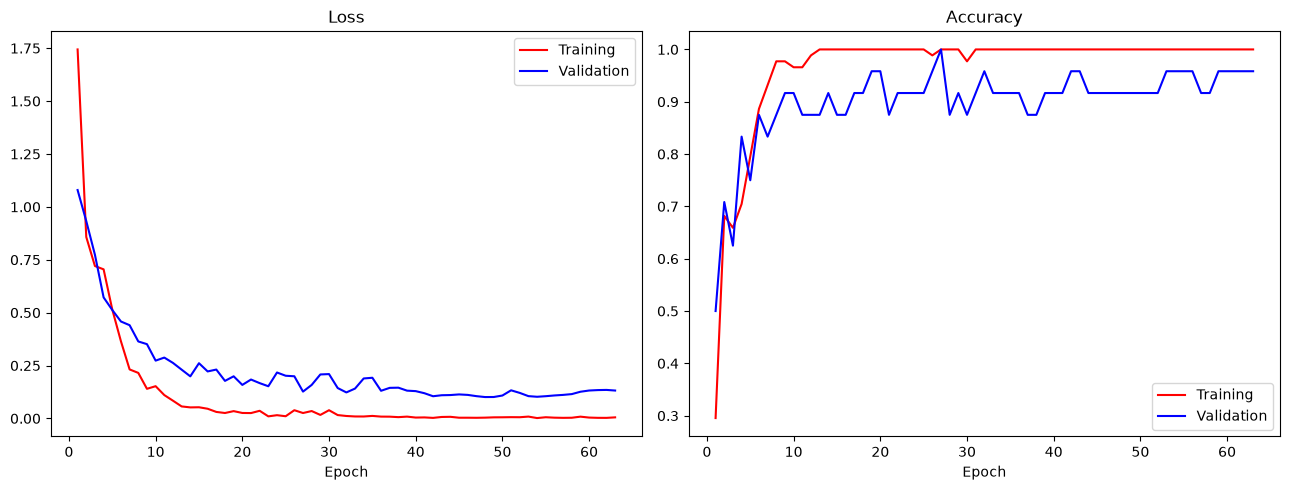

In [19]:
h = history.history
ep = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ep, h['loss'], 'r', label='Training')
axes[0].plot(ep, h['val_loss'], 'b', label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, h['accuracy'], 'r', label='Training')
axes[1].plot(ep, h['val_accuracy'], 'b', label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Tersimpan: {save_path}")

plt.show()


## Evaluasi pada validation

Tersimpan: results\confusion_matrix_validation.png


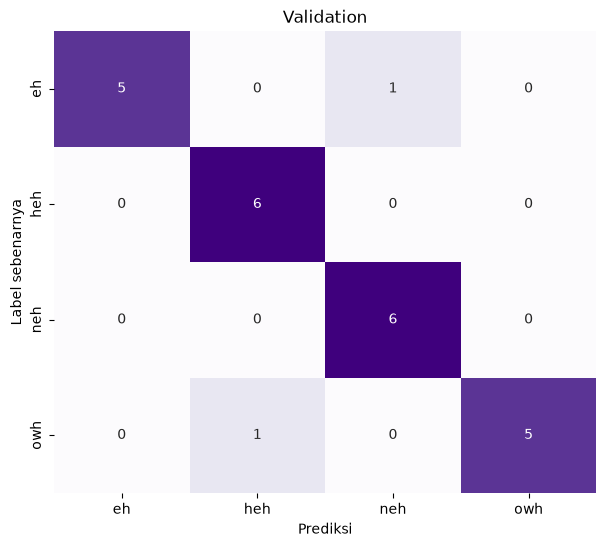

              precision    recall  f1-score   support

          eh     1.0000    0.8333    0.9091         6
         heh     0.8571    1.0000    0.9231         6
         neh     0.8571    1.0000    0.9231         6
         owh     1.0000    0.8333    0.9091         6

    accuracy                         0.9167        24
   macro avg     0.9286    0.9167    0.9161        24
weighted avg     0.9286    0.9167    0.9161        24

Accuracy : 0.9167
Macro F1 : 0.9161
Tersimpan: results\confusion_matrix_validation.txt


In [20]:
def report(dataset, df, judul, cmap, save_name):
    y_true = df['label'].values
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)

    plt.figure(figsize=(7, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cbar=False, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.ylabel('Label sebenarnya'); plt.xlabel('Prediksi'); plt.title(judul)

    png_path = os.path.join(RESULTS_DIR, f'{save_name}.png')
    plt.savefig(png_path, dpi=150, bbox_inches='tight')
    print(f"Tersimpan: {png_path}")
    plt.show()

    report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                        digits=4, zero_division=0)
    acc = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(report_text)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    txt_path = os.path.join(RESULTS_DIR, f'{save_name}.txt')
    with open(txt_path, 'w') as f:
        f.write(f"{judul}\n\n")
        f.write(report_text)
        f.write(f"\nAccuracy : {acc:.4f}\n")
        f.write(f"Macro F1 : {macro_f1:.4f}\n")
    print(f"Tersimpan: {txt_path}")

report(valid_dataset, valid_df, 'Validation', 'Purples', save_name='confusion_matrix_validation')


## Evaluasi TEST SET

Tersimpan: results\confusion_matrix_test.png


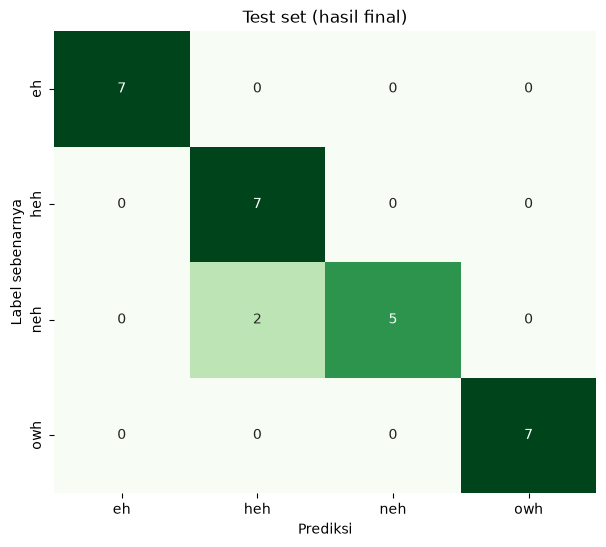

              precision    recall  f1-score   support

          eh     1.0000    1.0000    1.0000         7
         heh     0.7778    1.0000    0.8750         7
         neh     1.0000    0.7143    0.8333         7
         owh     1.0000    1.0000    1.0000         7

    accuracy                         0.9286        28
   macro avg     0.9444    0.9286    0.9271        28
weighted avg     0.9444    0.9286    0.9271        28

Accuracy : 0.9286
Macro F1 : 0.9271
Tersimpan: results\confusion_matrix_test.txt


In [21]:
report(test_dataset, test_df, 'Test set (hasil final)', 'Greens', save_name='confusion_matrix_test')

## Simpan model & inferensi video baru

In [ ]:
model.save('tangis_bayi_fusion.keras')

def predict_video(video_path):
    result = extract_video_sample(
        video_path,
        os.path.join(WORK_DIR, 'infer_frame'),
        os.path.join(WORK_DIR, 'infer_spec'),
    )
    if result is None:
        raise ValueError("Gagal mengekstrak citra/audio dari video ini.")
    frame_paths, spec_path = result

    frames = tf.expand_dims(tf.stack([load_frame(p) for p in frame_paths]), 0)
    spec   = tf.expand_dims(load_spec(spec_path), 0)

    probs = model.predict([frames, spec], verbose=0)[0]
    for cls, p in sorted(zip(CLASS_NAMES, probs), key=lambda kv: -kv[1]):
        print(f"  {cls:6s} ({MEANINGS[cls]:26s}) : {p:.4f}")
    hasil = CLASS_NAMES[int(np.argmax(probs))]
    print(f"\nPrediksi: {hasil} — {MEANINGS[hasil]}")
    return hasil

predict_video('Data_Video_Bayi/owh/data_test_video/o_0035.mp4')

  owh    (Mengantuk                 ) : 0.9999
  eh     (Perlu bersendawa          ) : 0.0001
  heh    (Tidak nyaman              ) : 0.0000
  neh    (Lapar                     ) : 0.0000

Prediksi: owh — Mengantuk


'owh'